In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## 1. Data Exploration:

a. Load the dataset and perform exploratory data analysis (EDA).

In [2]:
diab = pd.read_csv("C:/Users/shanm/Python_Practice/Datasets/diabetes.csv")
diab.head(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0


In [3]:
diab.shape

(768, 9)

In [4]:
diab.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
# All data types are valid

In [6]:
diab[diab.duplicated()]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


In [7]:
# There are no duplicate values

In [8]:
diab.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


b. Examine the features, their types, and summary statistics.

In [9]:
diab.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [10]:
corr = diab.corr()

<function matplotlib.pyplot.show(close=None, block=None)>

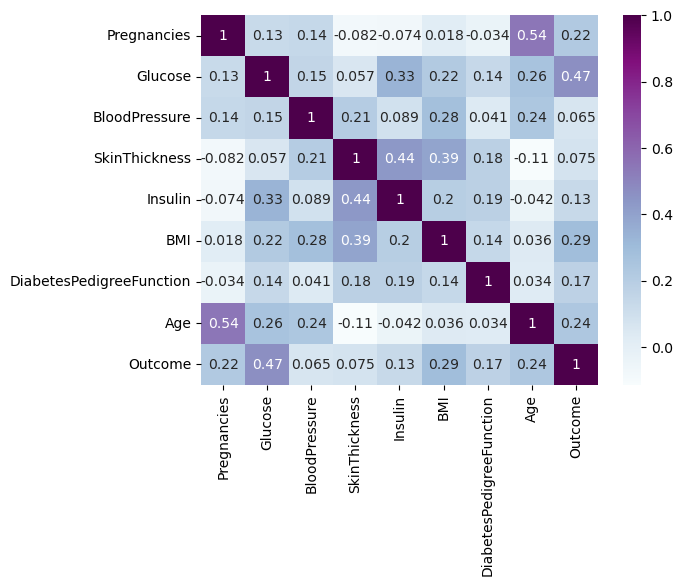

In [11]:
sns.heatmap(corr , annot=True , cmap="BuPu")
plt.show

Summary : 

- As per observation through correlation between features and Outcome , Glucose level, insulin , age and BMI contribute much to Outcome (whether a patient has diabetes or not)
- Age is highly co-related with Pregancies. As Age increases number of preganancy will decrease
- Skin thickness and Insulin are co-related well meaning that People with thicker skin may need high insulin

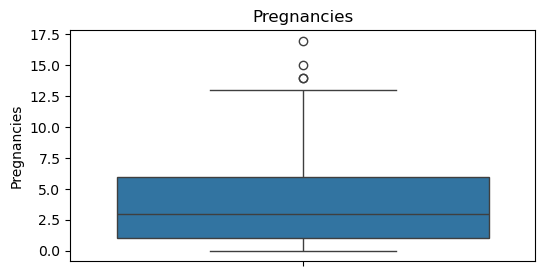

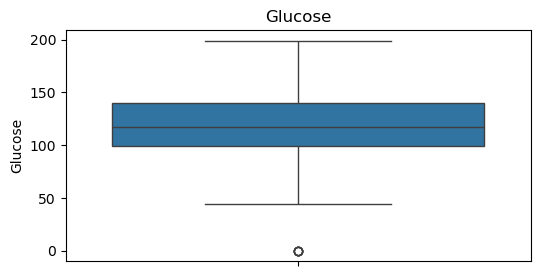

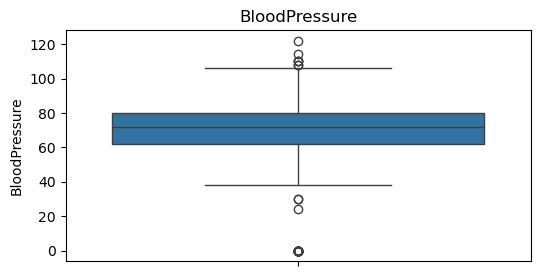

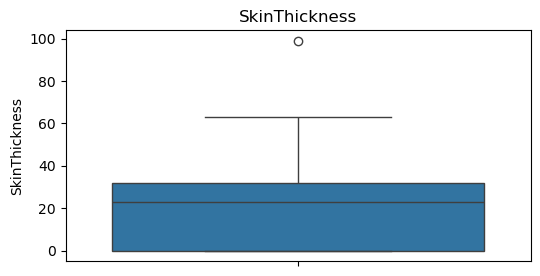

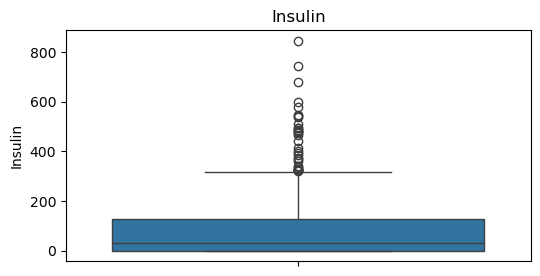

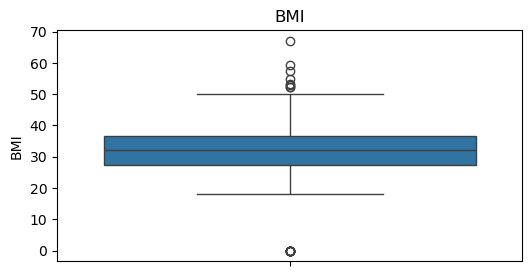

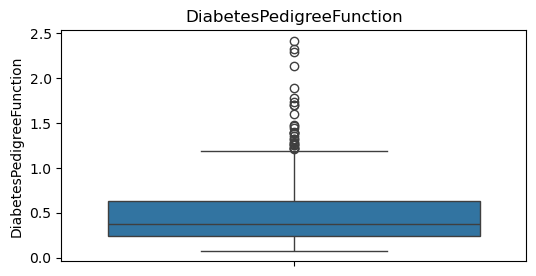

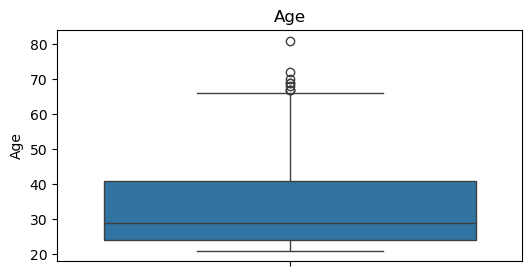

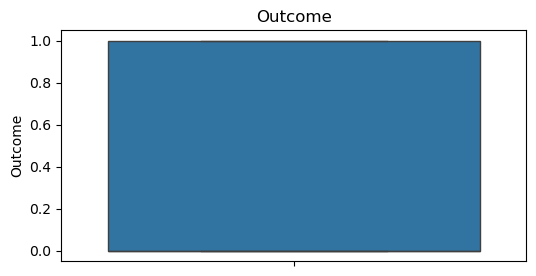

In [12]:
for col in diab.select_dtypes(include="number").columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(diab[col])
    plt.title(f"{col}")
    plt.show()

There are outliers visible in Diabetes Pedegree Function, BMI , Insulin , Blood Pressure and Preganancy

<Figure size 600x300 with 0 Axes>

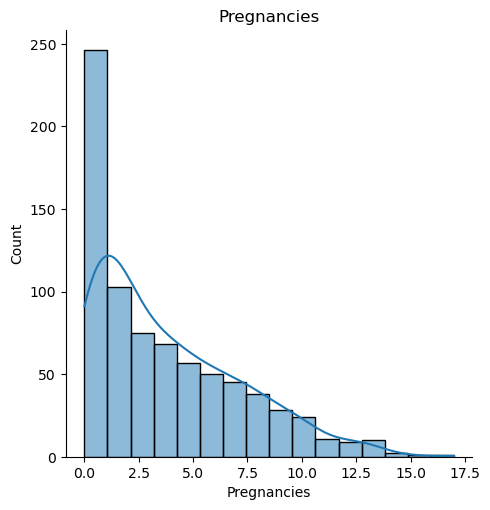

<Figure size 600x300 with 0 Axes>

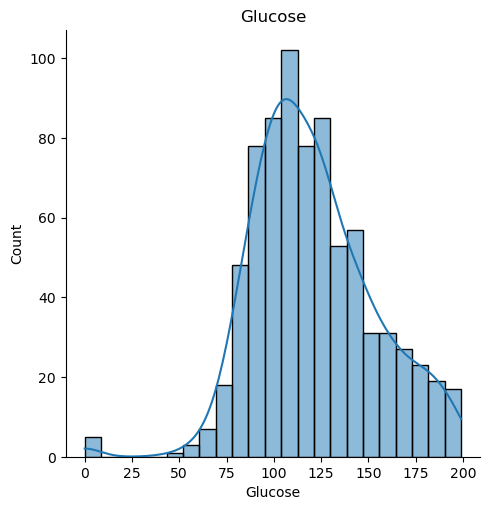

<Figure size 600x300 with 0 Axes>

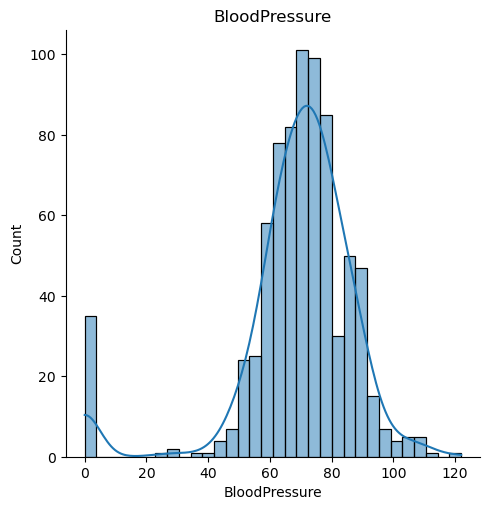

<Figure size 600x300 with 0 Axes>

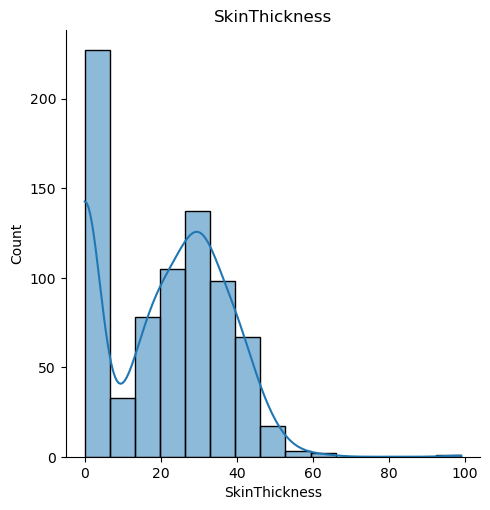

<Figure size 600x300 with 0 Axes>

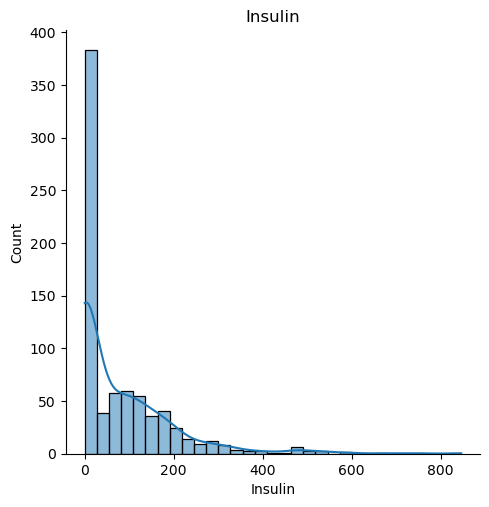

<Figure size 600x300 with 0 Axes>

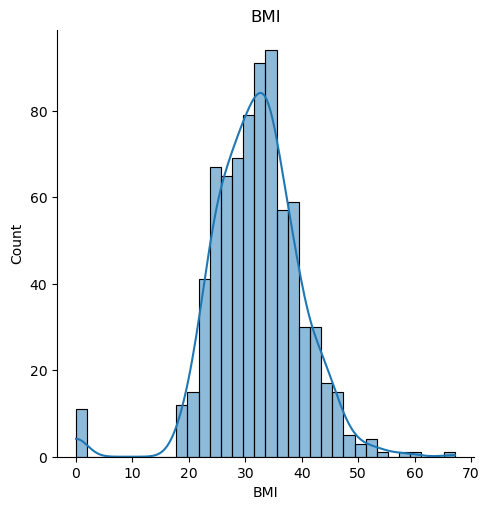

<Figure size 600x300 with 0 Axes>

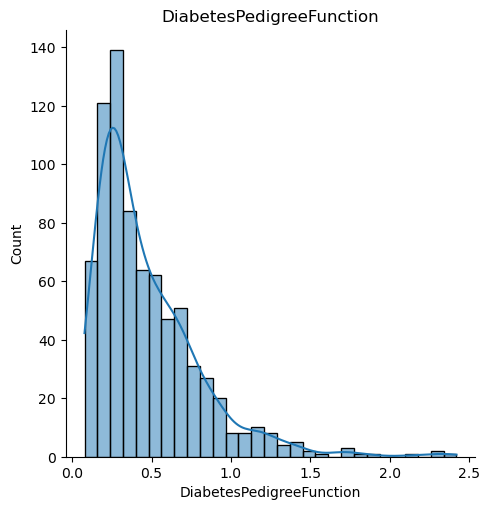

<Figure size 600x300 with 0 Axes>

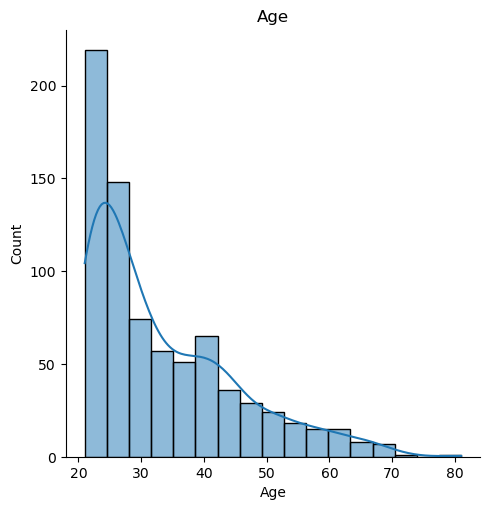

<Figure size 600x300 with 0 Axes>

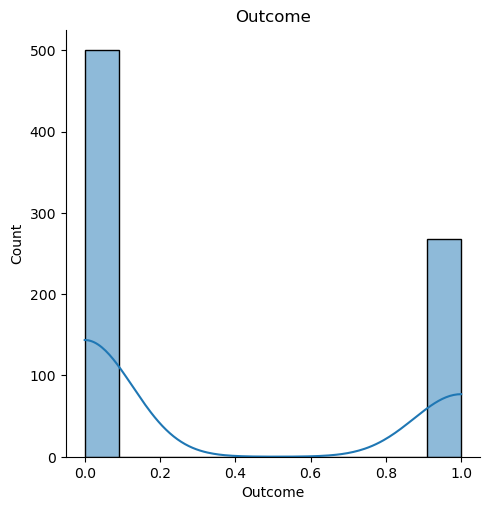

In [13]:
for col in diab.select_dtypes(include="number").columns:
    plt.figure(figsize=(6,3))
    sns.displot(diab , x=col , kind='hist' , kde=True)
    plt.title(f"{col}")
    plt.show()

Pregnancy, Age , Inslin ,DiabetesPedigreeFunction has a right skewed data. Insulin secreation reduces as i=age increase. Pregnancy reduce as age increases.

Lets treat outliers carefully since it is a medical data

- Blood Pressre = 0 are unreal values.Lets treat it
- Insulin and Pedigree function has extreme values in its right end. Its common that fewer patients has high insulin levels
- Pedigree function says whether diabetes come from genes. So it is also possible to have high values.Lets not treat it

In [14]:
def wisker(col):
    q1,q3 = np.percentile(diab[i] , [25,75])
    iqr = q3-q1
    lw = q1 -(1.5*iqr)
    uw = q3 + (1.5*iqr)
    return lw,uw

In [15]:
for i in ['BloodPressure','Age','Pregnancies']:
    lw,uw = wisker(diab[i])
    diab[i] = np.where(diab[i] < lw , lw , diab[i])
    diab[i] = np.where(diab[i]>uw,uw,diab[i])

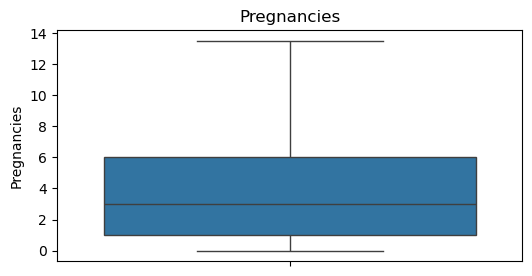

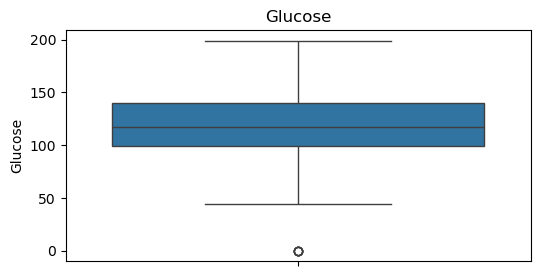

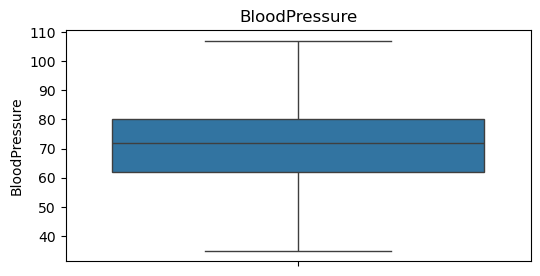

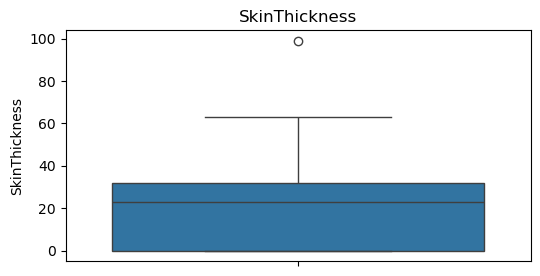

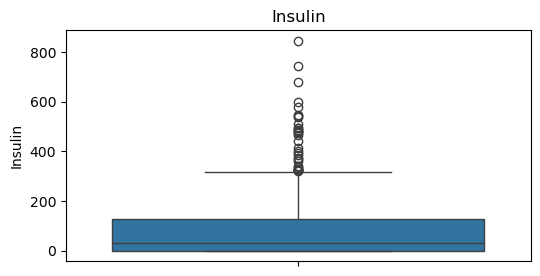

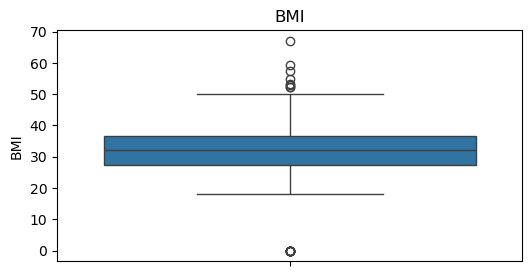

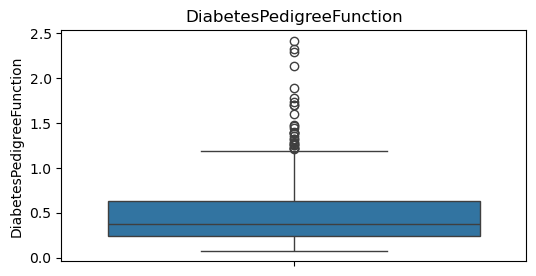

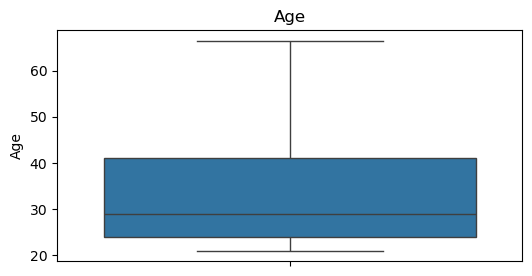

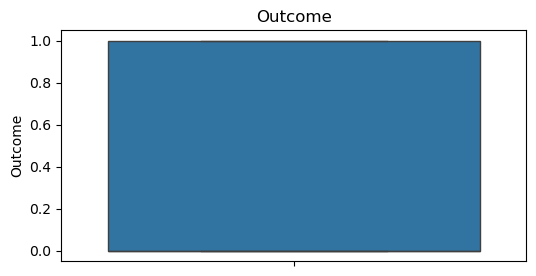

In [16]:
for col in diab.select_dtypes(include="number").columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(diab[col])
    plt.title(f"{col}")
    plt.show()

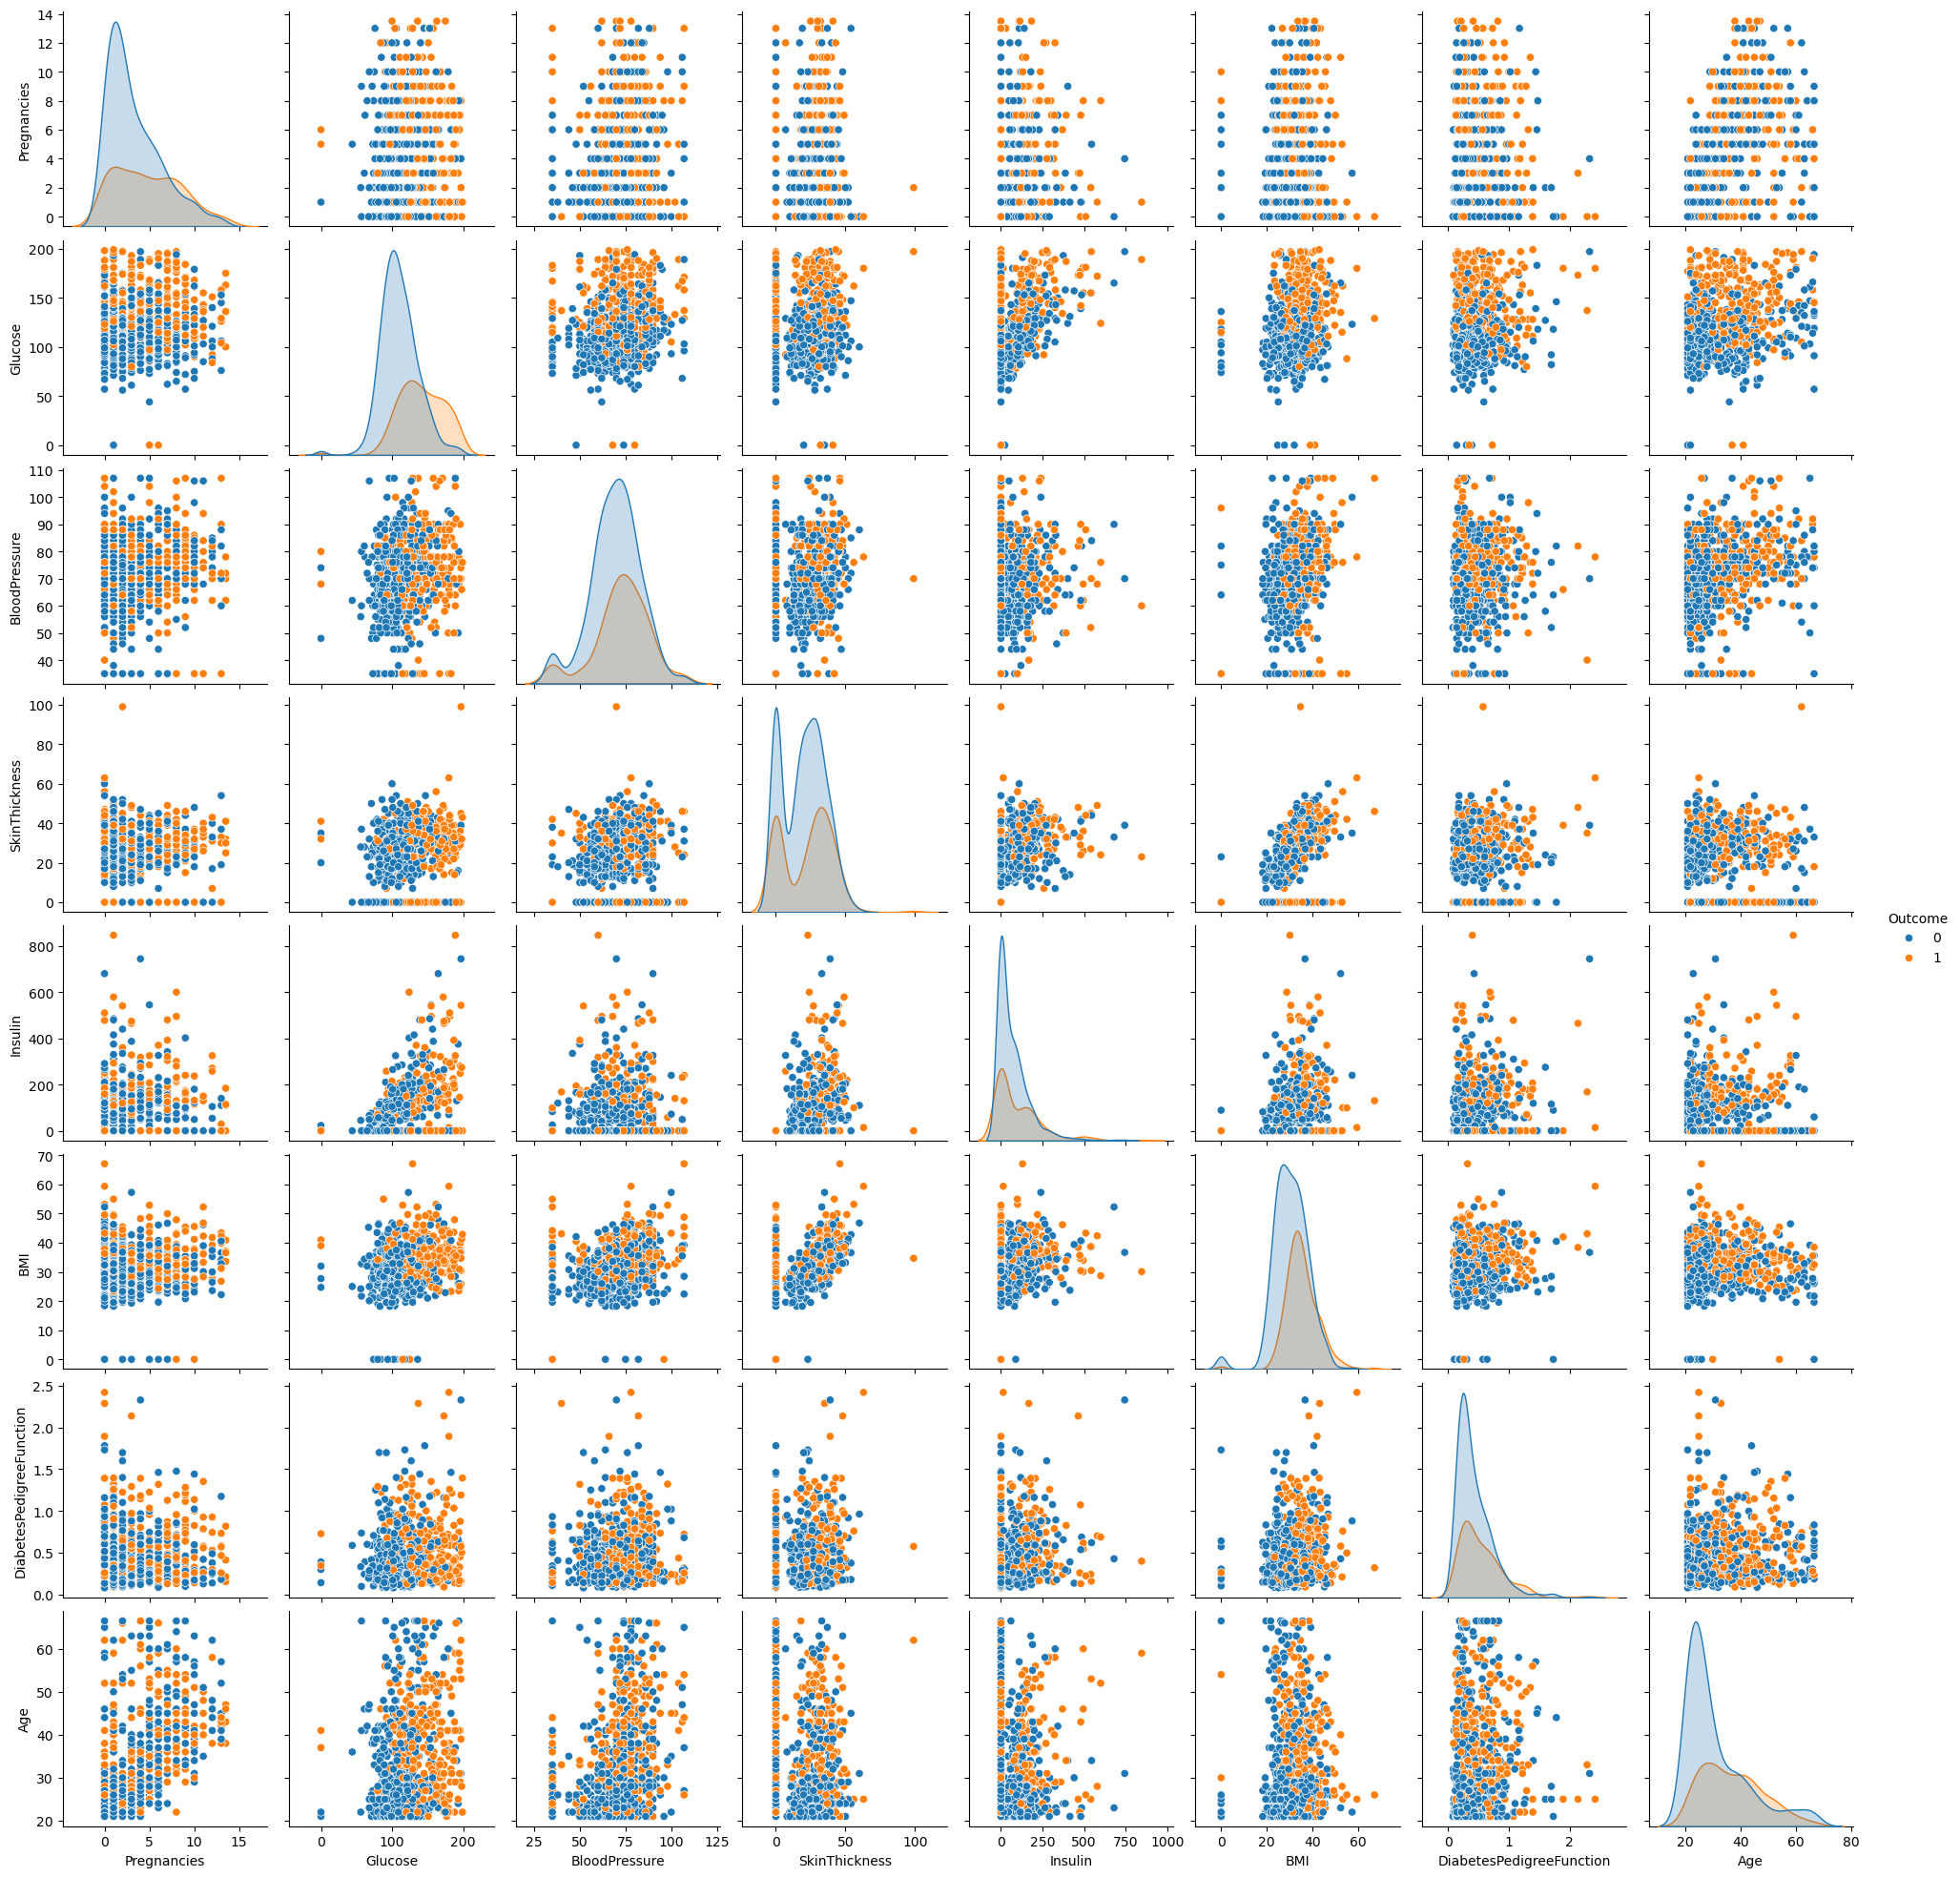

In [17]:
sns.pairplot(diab,hue='Outcome')
plt.show()

# 2. Data Preprocessing:

In [18]:
diab.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

There are no null values and there is no categorical value to be encoded .

In [19]:
# Lets scale the data

from sklearn.preprocessing import StandardScaler
num_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin','BMI', 'DiabetesPedigreeFunction', 'Age']
for i in num_cols :
    scaler = StandardScaler()
    diab[i] = scaler.fit_transform(diab[[i]])

In [20]:
diab.head(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.64715,0.848324,0.092691,0.907270,-0.692891,0.204013,0.468492,1.445691,1
1,-0.84897,-1.123396,-0.330201,0.530902,-0.692891,-0.684422,-0.365061,-0.189304,0


# 3. Model Building:

In [21]:
X = diab.iloc[:,:-1]
X.head(1)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.64715,0.848324,0.092691,0.90727,-0.692891,0.204013,0.468492,1.445691


In [22]:
y = diab.iloc[:,-1]
y.head(1)

0    1
Name: Outcome, dtype: int64

Lets handle 0's in the values as Practically in real world scenario , it is not possible to have 0 Glucose ,BP , Insulin , SkinThickness.These are not biologically possible ,they represent missing values, not real data.

In [23]:
cols_with_zero = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

diab[cols_with_zero] = diab[cols_with_zero].replace(0, np.nan)

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')

diab[cols_with_zero] = imputer.fit_transform(diab[cols_with_zero])

In [24]:
from sklearn.model_selection import train_test_split 
X_train , X_test , y_train , y_test = train_test_split(X, y , test_size=0.2, random_state=42)
X_train.shape , X_test.shape , y_train.shape , y_test.shape

((614, 8), (154, 8), (614,), (154,))

In [25]:
from sklearn.linear_model import LogisticRegression 

In [26]:
model = LogisticRegression(max_iter=200 , class_weight='balanced')

In [27]:
model.fit(X_train , y_train)

LogisticRegression(class_weight='balanced', max_iter=200)

In [28]:
yhat = model.predict(X_test)

In [29]:

y_prob = model.predict_proba(X_test)[:,1]

y_pred_custom = (y_prob > 0.3).astype(int)
y_pred_custom

array([1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1])

# 4. Model Evaluation:

In [30]:
from sklearn.metrics import confusion_matrix,classification_report

In [31]:
from sklearn.metrics import recall_score,precision_score, f1_score

In [32]:
# Calculate recall

recall = recall_score(y_test,y_pred_custom)
print("recall",recall)

precision = precision_score(y_test,y_pred_custom)
print("precision_score",precision)

f1 = f1_score(y_test,y_pred_custom)
print("f1_score",np.round(f1,2))


recall 0.8909090909090909
precision_score 0.48514851485148514
f1_score 0.63


In [33]:
# Confusion matrix 

cm = confusion_matrix(y_test,y_pred_custom)
cm

array([[47, 52],
       [ 6, 49]], dtype=int64)

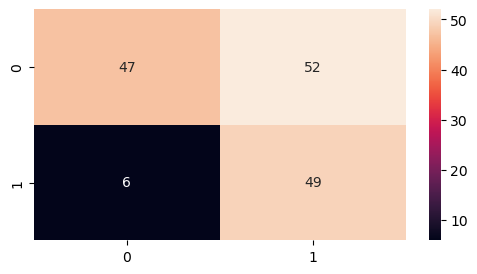

In [34]:
plt.figure(figsize=(6,3))
sns.heatmap(cm, annot=True )
plt.show()

In [35]:
from sklearn.metrics import  roc_curve ,roc_auc_score
def plot_auc_roc(y,yhat):
    fpr , tpr , thresh = roc_curve(y,yhat)
    auc = roc_auc_score(y,yhat)
    print(f'AUC: {auc}')
    plt.figure(figsize=(3,3))

    plt.title('AUC - ROC Curve', fontsize=15)
    plt.xlabel('False Positive Rate(FPR)')
    plt.ylabel('True Positive Rate(TPR)')

    plt.plot(fpr,tpr)
    plt.plot([0,1],[0,1] , "o--")
    plt.show()
    

AUC: 0.6979797979797979


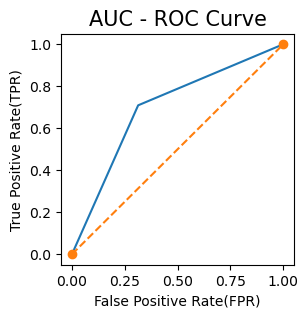

In [36]:
plot_auc_roc(y_test,yhat)

# 5. Interpretation:

In [37]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.01, 0.1, 1, 10, 50]}

grid = GridSearchCV(
    LogisticRegression(max_iter=500, class_weight='balanced'),
    param_grid,
    scoring='f1',
    cv=5
)

grid.fit(X_train, y_train)

grid.best_params_

{'C': 1}

# 6. Deployment with Streamlit:

In [41]:
from pickle import dump

In [42]:
dump(model , open('model.pkl','wb'))